<a href="https://colab.research.google.com/github/gonzalezzayra/Procesos-Estocasticos-/blob/main/Descomposici%C3%B3n_Can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Descomposición Canónica**

$$
P=
\begin{pmatrix}
1/4 & 0 & 0 & 0 & 0 & 0 & 3/4 \\
1/8 & 1/8 & 1/4 & 0 & 1/4 & 1/8 & 1/8 \\
0 & 0 & 2/5 & 1/5 & 2/5 & 0 & 0 \\
0 & 0 & 1/2 & 1/2 & 0 & 0 & 0 \\
0 & 0 & 0 & 1/2 & 1/2 & 0 & 0 \\
0 & 1/5 & 0 & 1/5 & 1/5 & 1/5 & 1/5 \\
4/5 & 0 & 0 & 0 & 0 & 0 & 1/5
\end{pmatrix}
$$

1. Escriba la matriz P de la imagen anexa y dibuje su diagrama de transiciones.


In [61]:
#Importar librerías
import numpy as np #numpy para operaciones matematicas
import networkx as nx #Networkx para los grafos
import matplotlib.pyplot as plt #para graficar
import sympy as sp #para las matrices

In [62]:
#Definimos los estados de la 'a' a la 'g'
estados= ['a', 'b', 'c', 'd', 'e', 'f', 'g']

#Definir la matriz P
P= [
    [1/4,  0,   0,   0,   0,   0, 3/4],
    [1/8, 1/8, 1/4,  0, 1/4, 1/8, 1/8],
    [ 0,   0, 2/5, 1/5, 2/5,  0,   0],
    [ 0,   0, 1/2, 1/2,  0,   0,   0],
    [ 0,   0,  0,  1/2, 1/2,  0,   0],
    [ 0,  1/5,  0, 1/5, 1/5, 1/5, 1/5],
    [4/5,  0,   0,   0,   0,   0, 1/5]
]

#print(P) #Para ver si esta bien definida la matriz

#Para dibujar el diagrama de transiciones

#Se define G como el grafo
G=nx.DiGraph()

#Un ciclo for para que se forme los 'arcos' del grafo
for i in range(len(estados)):
    for j in range(len(estados)):
        if P[i][j] > 0:
            G.add_edge(estados[i], estados[j], weight=round(P[i][j], 3)) #Se redondea a 3 decimales

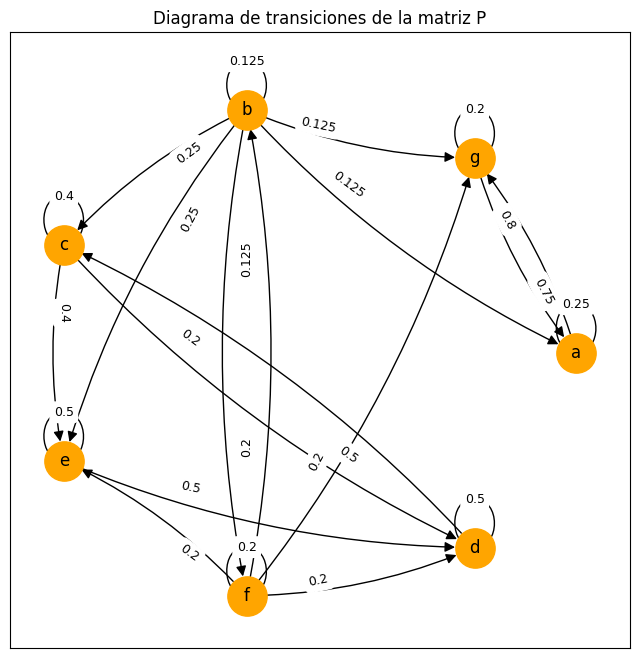

In [63]:
#Dibujo del grafo

plt.figure(figsize=(8, 8)) #Definir la región del grafo para que se pueda ver todo el grafo

#Se define el diseño circular
posiciones = nx.circular_layout(G)

#Dibujar los nodos
nx.draw_networkx_nodes(G, posiciones, node_color='orange', node_size=800)
nx.draw_networkx_labels(G, posiciones, font_size=12)

#Dibujar los arcos
nx.draw_networkx_edges(G, posiciones, connectionstyle='arc3, rad=0.1', node_size=800, arrowsize=15)

#Para que los valores de las probabilidades puedan visualizarse en el grafo
etiquetas = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, posiciones, edge_labels=etiquetas, font_size=9, label_pos=0.3)

plt.title("Diagrama de transiciones de la matriz P")
plt.show()

2. Determine si la matriz tiene o no distribución límite.

In [64]:
#Con ayuda de sympy con la matriz P, para poner elvarla a una potencia
Ps = sp.Matrix(P)

#Elevamos a la potencia 100
P_100 = Ps**100

print("Fila límite si empezamos en 'a':")
sp.pprint(P_100[0, :]) #Como a es la fila 0

print("\nFila límite si empezamos en 'c':")
sp.pprint(P_100[2, :]) #Como c es la fila 2

print("Como las filas son distintas, comprobamos que no hay un límite único")

Fila límite si empezamos en 'a':
[0.516129032258066  0  0  0  0  0  0.483870967741937]

Fila límite si empezamos en 'c':
[0  0  0.333333333333334  0.4  0.266666666666667  0  0]
Como las filas son distintas, comprobamos que no hay un límite único


3. Escriba la descomposición canónica de la matriz, determine el límite de la potencia n-esima y compare contra las distribuciones límite de las submatrices.

**Análisis de los Estados:**
* **Estados transitorios:** $\{b, f\}$
* **Estados recurrentes:** Se agrupan en dos clases cerradas distintas, $\{a, g\}$ y $\{c, d, e\}$.

**Clasificación de la cadena:
La matriz es estocástica. Sin embargo, al existir más de una clase de comunicación, se concluye que la cadena es reducible. Como consecuencia directa, también es no regular y no ergódica.